## Initial notebook for data exploration (ham10000)

Basic inspection Load 10–20 random images.
Display image + (if available) mask overlay. 
Verify: Image resolution Mask alignment Class distribution

## Data directory
###  Dataset Storage (Local Only)

This folder contains datasets used for the **DermaXplain** practicum project.
**All contents of this directory are excluded from version control** and must be downloaded locally by each collaborator.

### Directory Structure
```
data/
|--- isic2018/
│    |--- images/
│    |--- masks/
|--- ham10000/
│    |--- images/
|    |--- masks/
│    |--- metadata.csv
```

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Adjust if this notebook is not in <dir>/
ROOT = Path("..")
ISIC_DIR = ROOT / "data" / "isic2018"
ISIC_IMG_DIR  = ISIC_DIR / "images"
ISIC_MASK_DIR = ISIC_DIR / "masks"

HAM_DIR = ROOT / "data" / "ham10000"
HAM_IMG_DIR = HAM_DIR / "images"
HAM_META = HAM_DIR / "HAM10000_metadata.csv"
HAM_MASK_DIR = HAM_DIR / "masks"  # Tschandl masks unzipped

assert ISIC_IMG_DIR.exists(), f"Missing {ISIC_IMG_DIR}"
assert ISIC_MASK_DIR.exists(), f"Missing {ISIC_MASK_DIR}"
assert HAM_IMG_DIR.exists(), f"Missing {HAM_IMG_DIR.resolve()}"
assert HAM_MASK_DIR.exists(), f"Missing {HAM_MASK_DIR.resolve()}"

In [2]:
import sys, torch
print(sys.executable)
print(torch.__version__)
print(torch.cuda.is_available())

/home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/.venv/bin/python
2.11.0.dev20251230+cu128
True


In [3]:
def load_rgb(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("RGB"))

def load_gray(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("L"))

def binarize_mask(mask_gray: np.ndarray) -> np.ndarray:
    return (mask_gray > 0).astype(np.uint8)

def overlay_mask(img_rgb: np.ndarray, mask_bin: np.ndarray, alpha: float = 0.4) -> np.ndarray:
    # <color> overlay on lesion pixels
    overlay = img_rgb.copy()
    red = np.array([255, 0, 0], dtype=np.uint8)
    blue = np.array([0, 0, 255], dtype=np.uint8)
    gray = np.array([128, 128, 128], dtype=np.uint8)
    lesion = mask_bin.astype(bool)
    overlay[lesion] = ( (1 - alpha) * overlay[lesion] + alpha * blue ).astype(np.uint8)
    return overlay

def find_mask_for_image(mask_dir: Path, img_path: Path) -> Path | None:
    # Common HAM naming: same stem with .png
    direct = mask_dir / f"{img_path.stem}_segmentation.png"
    return direct

In [4]:
from pathlib import Path
print("CWD:", Path.cwd())
print("HAM_IMG_DIR:", HAM_IMG_DIR)
print("HAM_IMG_DIR resolved:", HAM_IMG_DIR.resolve())
print("JPG count:", len(list(HAM_IMG_DIR.rglob("*.jpg"))))

CWD: /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/src
HAM_IMG_DIR: ../data/ham10000/images
HAM_IMG_DIR resolved: /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/data/ham10000/images
JPG count: 10015


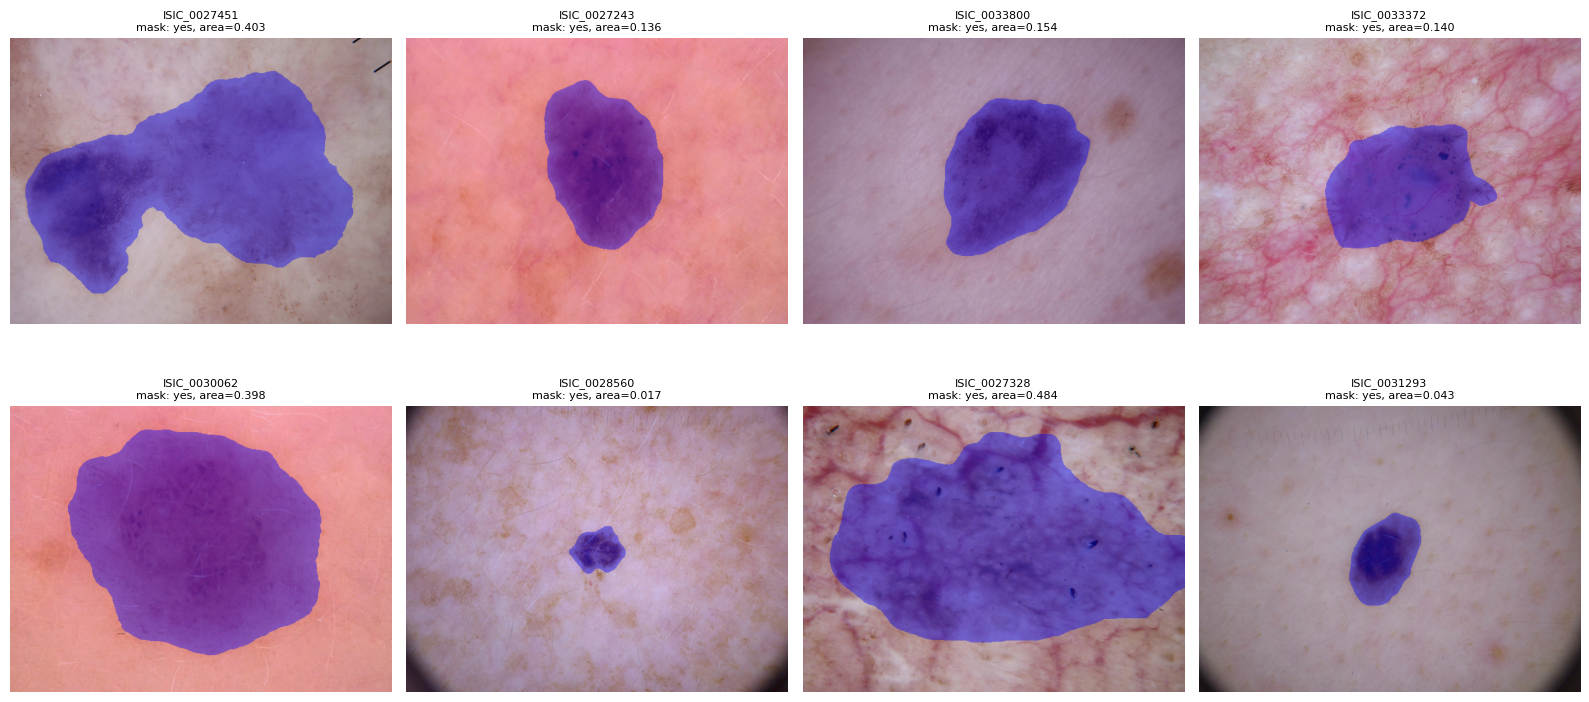

Sampled: 8
Example resolutions (H,W): [(450, 600), (450, 600), (450, 600), (450, 600), (450, 600)]
Mask area fraction (mean over sample): 0.22181203703703703


In [5]:
N = 8  # change to 10–20 as needed

img_paths = sorted(list(HAM_IMG_DIR.glob("*.jpg")) + list(HAM_IMG_DIR.glob("*.png")))
assert img_paths, f"No images found in {HAM_IMG_DIR}"

sample = random.sample(img_paths, k=N)

cols = 4
rows = int(np.ceil(len(sample) / cols))
plt.figure(figsize=(4*cols, 4*rows))

resolutions = []
mask_area_fracs = []

for i, img_path in enumerate(sample, start=1):
    img = load_rgb(img_path)
    resolutions.append(img.shape[:2])

    mask_path = find_mask_for_image(HAM_MASK_DIR, img_path)
    if mask_path:
        mask_bin = binarize_mask(load_gray(mask_path))
        mask_area = mask_bin.mean()
        mask_area_fracs.append(mask_area)
        vis = overlay_mask(img, mask_bin)
        title = f"{img_path.stem}\nmask: yes, area={mask_area:.3f}"
    else:
        vis = img
        title = f"{img_path.stem}\nmask: NO"

    plt.subplot(rows, cols, i)
    plt.imshow(vis)
    plt.axis("off")
    plt.title(title, fontsize=8)

plt.tight_layout()
plt.show()

print("Sampled:", len(sample))
print("Example resolutions (H,W):", resolutions[:5])
if mask_area_fracs:
    print("Mask area fraction (mean over sample):", float(np.mean(mask_area_fracs)))


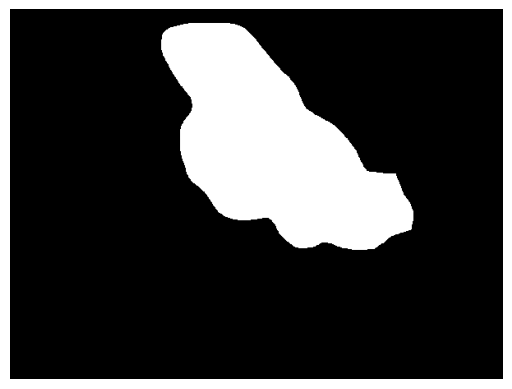

In [7]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_path = Path("/home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/data/ham10000/masks/ISIC_0034305_segmentation.png")

img = mpimg.imread(img_path)
plt.imshow(img, cmap="gray")  # drop cmap if you want RGB
plt.axis("off")
plt.show()

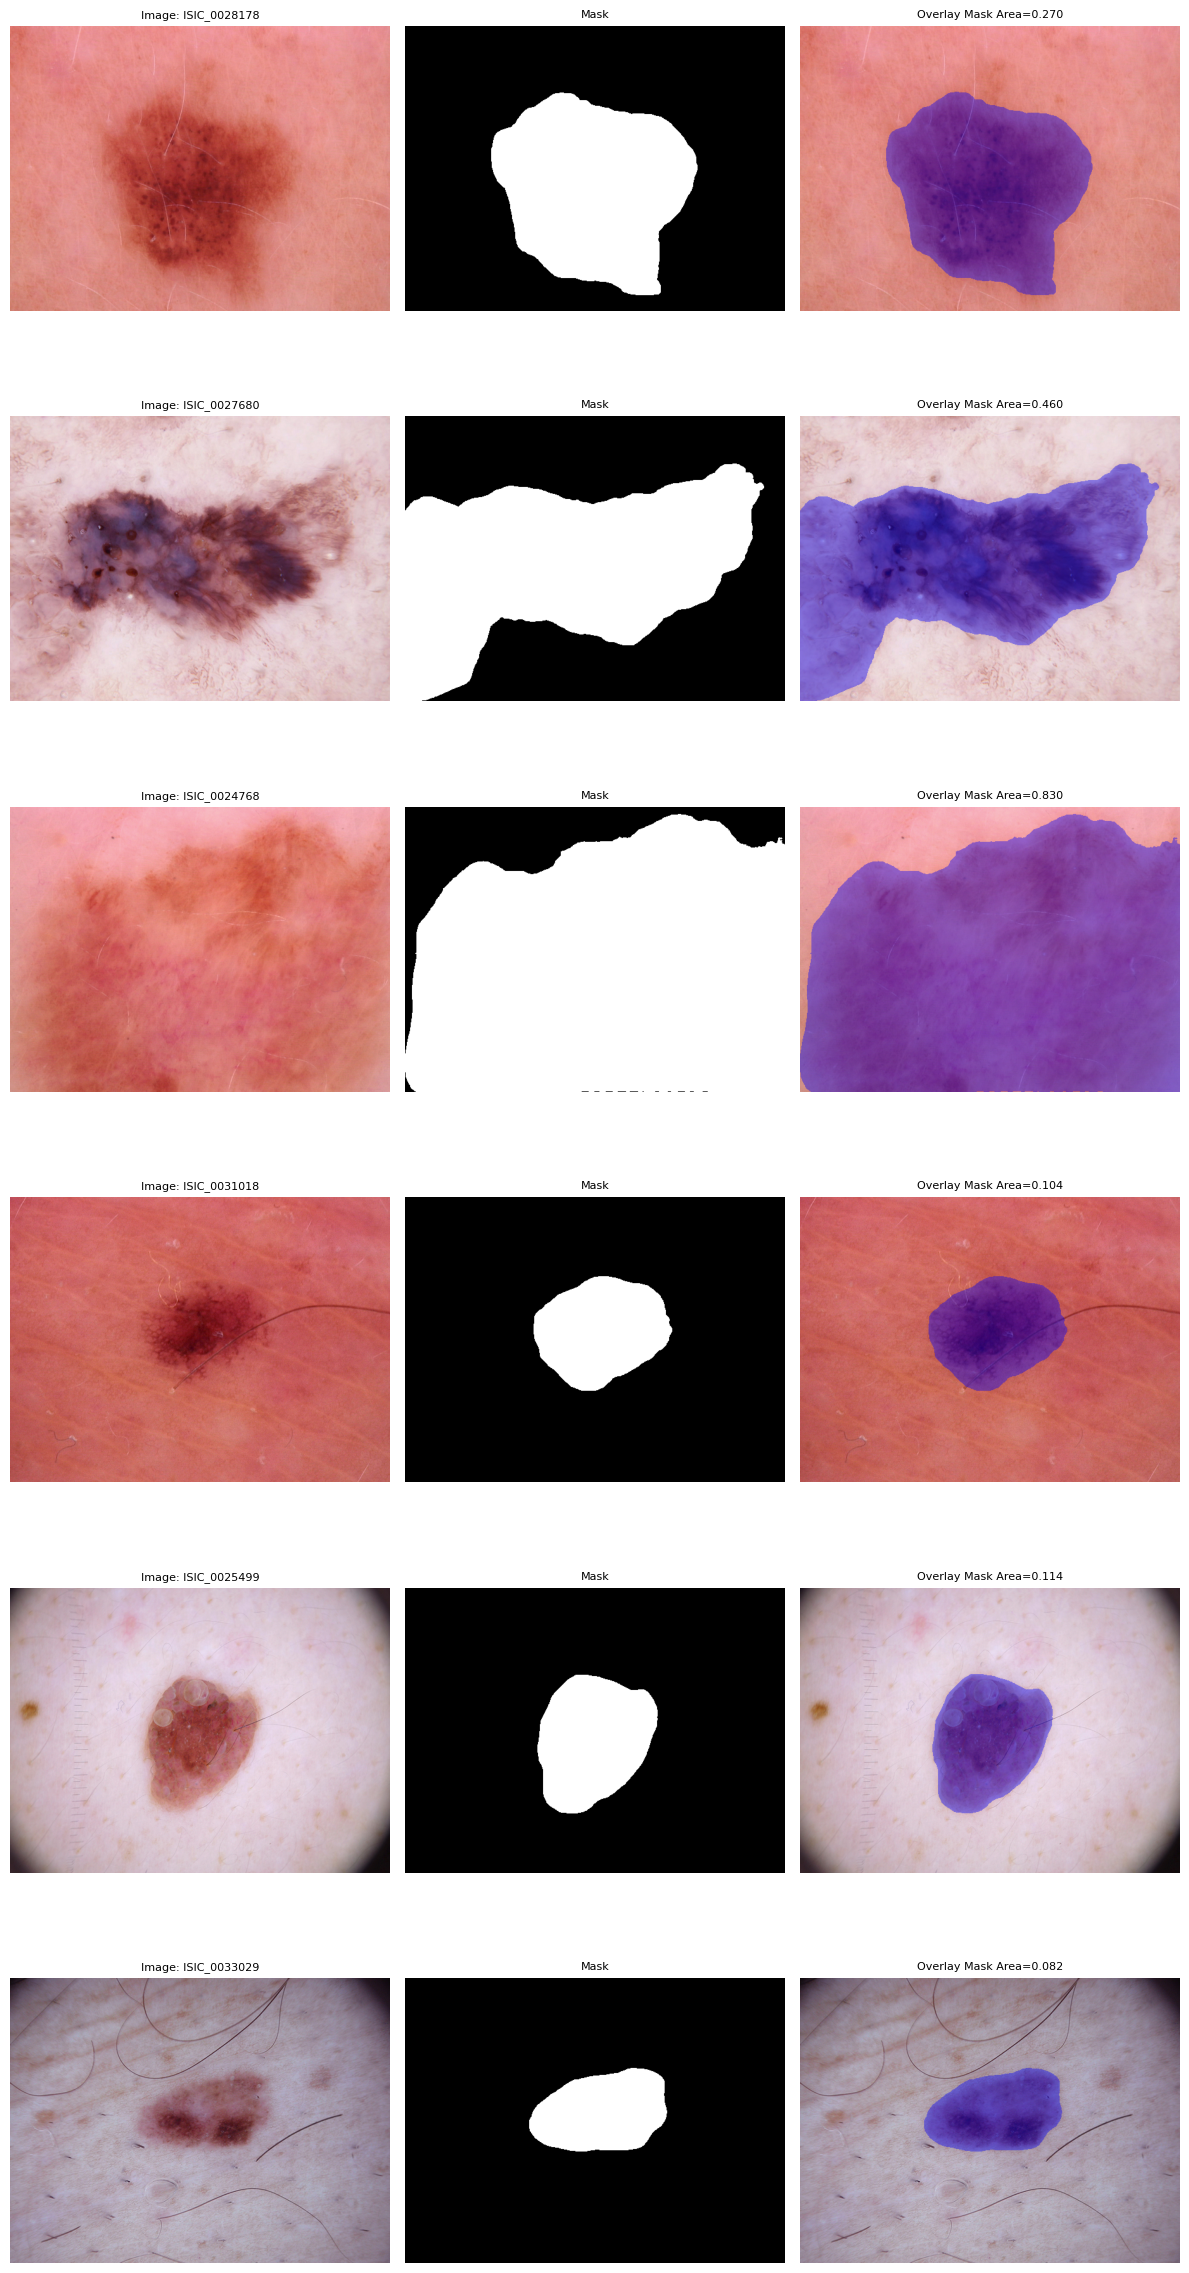

In [8]:
# load triples: img, mask, img + mask_overlay
def load_image_mask_overlay(img_path: Path, mask_dir: Path, alpha: float = 0.4) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    img = load_rgb(img_path)
    mask_path = find_mask_for_image(mask_dir, img_path)
    if not mask_path:
        raise ValueError(f"No mask found for image {img_path}")
    mask_bin = binarize_mask(load_gray(mask_path))
    mask_area = mask_bin.mean()
    overlay = overlay_mask(img, mask_bin, alpha=alpha)
    return img, mask_bin, mask_area, overlay

# plot n random samples from HAM : img, mask, image+mask_overlay  
N = 6  # number of samples
img_paths = sorted(list(HAM_IMG_DIR.glob("*.jpg")) + list(HAM_IMG_DIR.glob("*.png")))
assert img_paths, f"No images found in {HAM_IMG_DIR}"

sample = random.sample(img_paths, k=N)

cols = 3
rows = N
plt.figure(figsize=(4*cols, 4*rows)) 
for i, img_path in enumerate(sample, start=1):
    img, mask_bin, mask_area, overlay = load_image_mask_overlay(img_path, HAM_MASK_DIR, alpha=0.4)
    plt.subplot(rows, cols, (i-1)*cols + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image: {img_path.stem}", fontsize=8)

    plt.subplot(rows, cols, (i-1)*cols + 2)
    plt.imshow(mask_bin, cmap="grey")
    plt.axis("off")
    plt.title(f"Mask", fontsize=8)

    plt.subplot(rows, cols, (i-1)*cols + 3)
    plt.imshow(overlay)
    plt.axis("off")
    plt.title(f"Overlay Mask Area={mask_area:.3f}", fontsize=8)

plt.tight_layout()
plt.show()